In [ ]:
import os
import io
import torch
import numpy as np
from PIL import Image
from transformers import AutoImageProcessor, AutoModelForImageClassification
import time
from skimage import data
from IPython.display import display



In [ ]:
# --- MODEL SETUP ---
print(" Loading Hugging Face ViT model...")
model_name = "google/vit-base-patch16-224"
processor = AutoImageProcessor.from_pretrained(model_name)

# We request the hidden states from the model
model = AutoModelForImageClassification.from_pretrained(
    model_name, output_attentions=True,output_hidden_states=True
)

# The user decides where the model lives
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f" Using device: {device.upper()}")
model.to(device)



 Loading Hugging Face ViT model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:121: UserWarning: 
Access to the secret `HF_TOKEN` has not been granted on this notebook.
You will not be requested again.
Please restart the session if you want to be prompted again.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

 Using device: CPU


ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (layers): ModuleList(
      (0-11): 12 x ViTLayer(
        (attention): ViTAttention(
          (q_proj): Linear(in_features=768, out_features=768, bias=True)
          (k_proj): Linear(in_features=768, out_features=768, bias=True)
          (v_proj): Linear(in_features=768, out_features=768, bias=True)
          (o_proj): Linear(in_features=768, out_features=768, bias=True)
        )
        (layernorm_before): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (layernorm_after): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
        (mlp): ViTMLP(
          (activation_fn): GELUActivation()
          (fc1): Linear(in_features=768, out_features=3072, bias=True)
          (fc2): Linear(in_features=3072, out

In [ ]:
# --- BRIDGE FUNCTION ---
def hf_prediction_function(images_numpy):
    imgs_pil = [Image.fromarray((img).astype('uint8')) for img in images_numpy]
    inputs = processor(images=imgs_pil, return_tensors="pt").to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    return torch.nn.functional.softmax(outputs.logits, dim=-1).cpu().numpy()


In [ ]:
# --- LOAD TEST IMAGE ---
print("Loading local test image (Chelsea the cat)...")

image_np = data.chelsea()
test_image = Image.fromarray(image_np).convert("RGB").resize((224, 224))

Loading local test image (Chelsea the cat)...


 Initializing GlassBox-ViT (LimeExplainer)...


  0%|          | 0/500 [00:00<?, ?it/s]

 LIME generated in 364.32 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 364.32


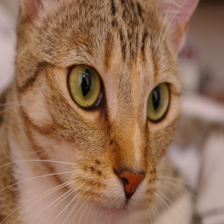

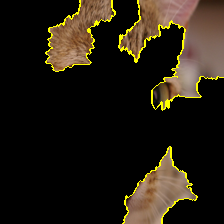

In [ ]:
from glassbox_vit import LimeExplainer


# --- INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (LimeExplainer)...")
explainer = LimeExplainer(prediction_function=hf_prediction_function)



# We time how long it takes
start_lime = time.time()


result = explainer.generate(pil_image=test_image, num_samples=500)

end_lime = time.time()
taken_time = end_lime - start_lime
print(f" LIME generated in {taken_time:.2f} seconds")

# --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['lime_image'])


 Initializing GlassBox-ViT (ShapExplainer)...


  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 2it [06:24, 384.56s/it]              


 SHAP generated in 423.43 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 423.43


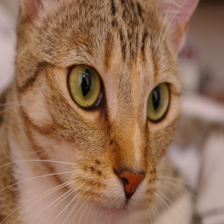

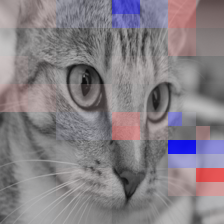

In [ ]:
from glassbox_vit import ShapExplainer

class_names = list(model.config.id2label.values())

# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (ShapExplainer)...")
explainer = ShapExplainer(
    prediction_function=hf_prediction_function,
    class_names=class_names
)

start_time = time.time()
# Generate function
result = explainer.generate(pil_image=test_image, max_evals=500)


end_time = time.time()
taken_time = end_time - start_time
print(f" SHAP generated in {taken_time:.2f} seconds")

# --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['shap_image'])


 Initializing GlassBox-ViT (RiseExplainer)...
 RISE generated in 1326.21 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 1326.21


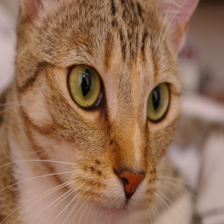

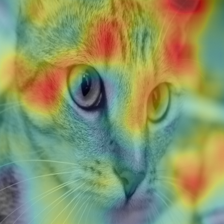

In [ ]:
from glassbox_vit import RiseExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT (RiseExplainer)...")
explainer = RiseExplainer(
    prediction_function=hf_prediction_function)


start_time = time.time()


result = explainer.generate(pil_image=test_image,num_masks=2000,batch_size=32)

end_time = time.time()
taken_time = end_time - start_time
print(f" RISE generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['rise_image'])

 Initializing GlassBox-ViT ...
 PATCH OCCLUSION generated in 123.92 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 123.92


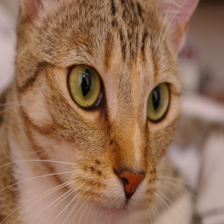

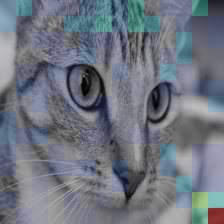

In [ ]:
from glassbox_vit import PatchOcclusionExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = PatchOcclusionExplainer(
    prediction_function=hf_prediction_function)


start_time = time.time()


result = explainer.generate(pil_image=test_image,batch_size=32,patch_size=16,mask_value=0)

end_time = time.time()
taken_time = end_time - start_time
print(f" PATCH OCCLUSION generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['patch_image'])

 Initializing GlassBox-ViT ...
 ATTENTION ROLLOUT generated in 1.14 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 1.14


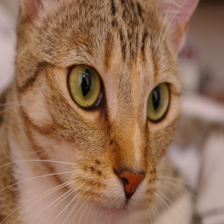

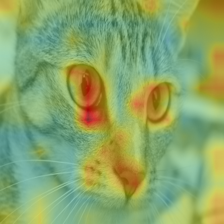

In [ ]:
from glassbox_vit import AttentionRolloutExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = AttentionRolloutExplainer(
    model=model,
    processor=processor
)

start_time = time.time()

result = explainer.generate(pil_image=test_image)

end_time = time.time()
taken_time = end_time - start_time
print(f" ATTENTION ROLLOUT generated in {taken_time:.2f} seconds")

# --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['rollout_image'])



 Initializing GlassBox-ViT ...
 GRADCAM generated in 3.16 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 3.16


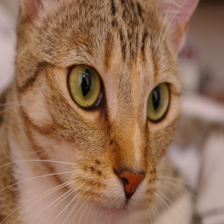

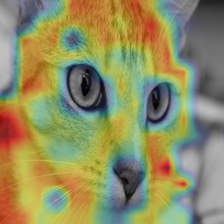

In [ ]:
from glassbox_vit import GradCamExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = GradCamExplainer(
    model=model,
    processor=processor
)

start_time = time.time()

result = explainer.generate(pil_image=test_image)

end_time = time.time()
taken_time = end_time - start_time
print(f" GRADCAM generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['gradcam_image'])

 Initializing GlassBox-ViT ...
 PCA generated in 1.12 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 1.12


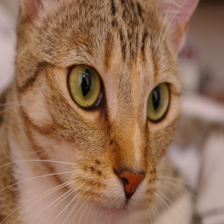

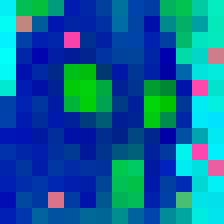

In [ ]:
from glassbox_vit import PCAExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = PCAExplainer(
    model=model,
    processor=processor
)

start_time = time.time()


result = explainer.generate(pil_image=test_image)

end_time = time.time()
taken_time = end_time - start_time
print(f" PCA generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['pca_image'])

 Initializing GlassBox-ViT ...
 SMOOTH GRAD generated in 105.91 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 105.91


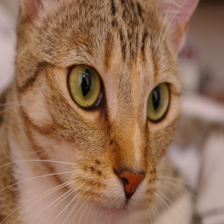

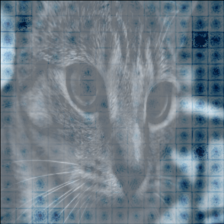

In [ ]:
from glassbox_vit import SmoothGradExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = SmoothGradExplainer(
    model=model,
    processor=processor
)

start_time = time.time()


result = explainer.generate(pil_image=test_image,num_samples=50, stdevs=0.15)

end_time = time.time()
taken_time = end_time - start_time
print(f" SMOOTH GRAD generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['smoothgrad_image'])

 Initializing GlassBox-ViT ...
 EXPECTED GRADIENTS generated in 93.73 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 93.73


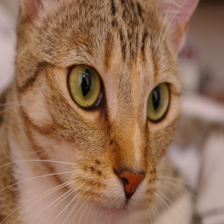

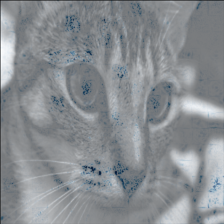

In [ ]:
from glassbox_vit import ExpectedGradientsExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = ExpectedGradientsExplainer(
    model=model,
    processor=processor
)

start_time = time.time()


result = explainer.generate(pil_image=test_image,baselines=None, n_samples=50)

end_time = time.time()
taken_time = end_time - start_time
print(f" EXPECTED GRADIENTS generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['eg_image'])

 Initializing GlassBox-ViT ...
 INTEGRATED GRADIENTS generated in 71.20 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 71.20


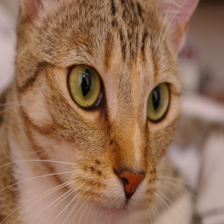

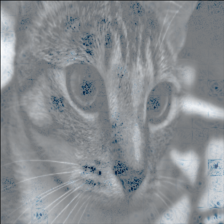

In [ ]:
from glassbox_vit import IntegratedGradientsExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = IntegratedGradientsExplainer(
    model=model,
    processor=processor
)

start_time = time.time()


result = explainer.generate(pil_image=test_image,baselines=None, n_steps=50)

end_time = time.time()
taken_time = end_time - start_time
print(f" INTEGRATED GRADIENTS generated in {taken_time:.2f} seconds")

        # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['ig_image'])

 Initializing GlassBox-ViT ...


100%|██████████| 48/48 [08:16<00:00, 10.34s/it]

 SCORECAM generated in 499.99 seconds

 TEST PASSED SUCCESSFULLY!
-> Model Prediction: Egyptian cat
-> Confidence: 97.55%
-> Time: 499.99


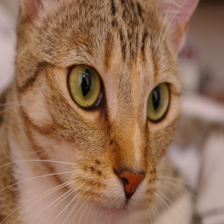

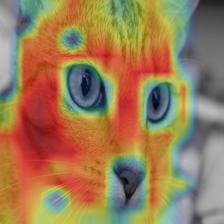

In [ ]:
from glassbox_vit import ScoreCamExplainer


# ---  INITIALIZE EXPLAINER ---
print(" Initializing GlassBox-ViT ...")
explainer = ScoreCamExplainer(
    model=model,
    processor=processor
)

start_time = time.time()


result = explainer.generate(pil_image=test_image)

end_time = time.time()
taken_time = end_time - start_time
print(f" SCORECAM generated in {taken_time:.2f} seconds")

       # --- DISPLAY RESULTS IN NOTEBOOK ---
# Extract predicted label and confidence
predicted_class = model.config.id2label[result['predicted_label_id']]
confidence = result['prediction_prob'] * 100

print("\n TEST PASSED SUCCESSFULLY!")
print(f"-> Model Prediction: {predicted_class}")
print(f"-> Confidence: {confidence:.2f}%")
print(f"-> Time: {taken_time:.2f}")

# Display the image directly in the notebook cell output
display(test_image)
display(result['scorecam_image'])